In [1]:
# Imports and load training data
import pandas as pd
import numpy as np
import os
import warnings
import time
warnings.filterwarnings('ignore')

from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# ── Paths ─────────────────────────────────────────────────────────────
PROCESSED_PATH = r"data\processed"
MODELS_PATH    = r"models"
SYNTHETIC_PATH = r"data\synthetic"

os.makedirs(MODELS_PATH,    exist_ok=True)
os.makedirs(SYNTHETIC_PATH, exist_ok=True)

# ── Load training data ─────────────────────────────────────────────────
train_df = pd.read_csv(os.path.join(PROCESSED_PATH, 'train_real.csv'))

print(f" Training data loaded")
print(f"  Shape:          {train_df.shape}")
print(f"  Patients:       {len(train_df):,}")
print(f"  Features:       {train_df.shape[1] - 1}")
print(f"  Mortality rate: {train_df['HOSPITAL_EXPIRE_FLAG'].mean()*100:.1f}%")

 Training data loaded
  Shape:          (25508, 34)
  Patients:       25,508
  Features:       33
  Mortality rate: 10.6%


In [2]:
# Tell SDV exactly what type each column is
# SDV needs this to apply the right transformation per column

# Separate columns by type
binary_cols = (
    ['GENDER', 'HOSPITAL_EXPIRE_FLAG'] +
    [c for c in train_df.columns if c.endswith('_missing')] +
    [c for c in train_df.columns if c.startswith('admtype_')] +
    [c for c in train_df.columns if c.startswith('insurance_')]
)

continuous_cols = (
    ['AGE', 'LOS'] +
    [c for c in train_df.columns if c.startswith('lab_') 
     and not c.endswith('_missing')]
)

print(f" Column types defined")
print(f"  Continuous columns ({len(continuous_cols)}): {continuous_cols}")
print(f"  Binary columns    ({len(binary_cols)}):     {binary_cols}")

 Column types defined
  Continuous columns (14): ['AGE', 'LOS', 'lab_base_excess', 'lab_bicarbonate', 'lab_bun', 'lab_creatinine', 'lab_glucose', 'lab_haemoglobin', 'lab_lactate', 'lab_ph', 'lab_platelets', 'lab_potassium', 'lab_sodium', 'lab_wbc']
  Binary columns    (20):     ['GENDER', 'HOSPITAL_EXPIRE_FLAG', 'lab_base_excess_missing', 'lab_bicarbonate_missing', 'lab_bun_missing', 'lab_creatinine_missing', 'lab_glucose_missing', 'lab_haemoglobin_missing', 'lab_lactate_missing', 'lab_ph_missing', 'lab_platelets_missing', 'lab_potassium_missing', 'lab_sodium_missing', 'lab_wbc_missing', 'admtype_EMERGENCY', 'admtype_URGENT', 'insurance_Medicaid', 'insurance_Medicare', 'insurance_Private', 'insurance_Self Pay']


In [3]:
# Build metadata object
# SDV uses this to understand your data structure
# and apply the correct internal transformations

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(train_df)

# Override column types manually for clinical accuracy
for col in continuous_cols:
    metadata.update_column(col, sdtype='numerical')

for col in binary_cols:
    metadata.update_column(col, sdtype='categorical')

print(" Metadata configured")
print(f"\nColumn type summary:")
for col, info in metadata.columns.items():
    print(f"  {col:<35} {info['sdtype']}")

 Metadata configured

Column type summary:
  AGE                                 numerical
  GENDER                              categorical
  LOS                                 numerical
  lab_base_excess                     numerical
  lab_bicarbonate                     numerical
  lab_bun                             numerical
  lab_creatinine                      numerical
  lab_glucose                         numerical
  lab_haemoglobin                     numerical
  lab_lactate                         numerical
  lab_ph                              numerical
  lab_platelets                       numerical
  lab_potassium                       numerical
  lab_sodium                          numerical
  lab_wbc                             numerical
  lab_base_excess_missing             categorical
  lab_bicarbonate_missing             categorical
  lab_bun_missing                     categorical
  lab_creatinine_missing              categorical
  lab_glucose_missing              

In [4]:
# Initialise CTGAN synthesizer
# These hyperparameters are based on recommended settings
# from the SDV documentation and Chen et al. (2024) benchmark

synthesizer = CTGANSynthesizer(
    metadata,
    epochs=300,           # number of training iterations
    batch_size=500,       # patients per training batch
    generator_dim=(256, 256),      # generator network size
    discriminator_dim=(256, 256),  # discriminator network size
    generator_lr=2e-4,             # generator learning rate
    discriminator_lr=2e-4,         # discriminator learning rate
    discriminator_steps=1,         # discriminator updates per generator update
    log_frequency=True,            # log loss per epoch
    verbose=True,                  # print training progress
    cuda=False                     # set True if you have a GPU
)

print(" CTGAN initialised")
print(f"\nHyperparameters:")
print(f"  Epochs:             300")
print(f"  Batch size:         500")
print(f"  Generator dims:     (256, 256)")
print(f"  Discriminator dims: (256, 256)")
print(f"  Learning rate:      2e-4")
print(f"  Device:             CPU")

 CTGAN initialised

Hyperparameters:
  Epochs:             300
  Batch size:         500
  Generator dims:     (256, 256)
  Discriminator dims: (256, 256)
  Learning rate:      2e-4
  Device:             CPU


In [5]:
# Train CTGAN
# This will take 20-60 minutes on CPU depending on your machine
# You will see generator and discriminator loss printed per epoch

print("=" * 50)
print("Starting CTGAN training...")
print("Expected time: 20-60 minutes on CPU")
print("=" * 50)

start_time = time.time()

synthesizer.fit(train_df)

end_time   = time.time()
train_mins = (end_time - start_time) / 60

print(f"\n CTGAN training complete")
print(f"  Training time: {train_mins:.1f} minutes")

Starting CTGAN training...
Expected time: 20-60 minutes on CPU


Gen. (-01.20) | Discrim. (+00.22): 100%|█████████████████████████████████████████████| 300/300 [28:43<00:00,  5.75s/it]


 CTGAN training complete
  Training time: 30.0 minutes


In [6]:
# Save trained model
# Always save immediately after training
# so you never have to retrain from scratch

model_path = os.path.join(MODELS_PATH, 'ctgan_model.pkl')
synthesizer.save(model_path)

print(f" CTGAN model saved → {model_path}")
print(f"  File size: "
      f"{os.path.getsize(model_path) / 1024 / 1024:.1f} MB")

 CTGAN model saved → models\ctgan_model.pkl
  File size: 5.4 MB


In [7]:
# Generate synthetic patient records
# We generate the same number as the training set
# so evaluation comparisons are fair

N_SYNTHETIC = len(train_df)  # match training set size

print(f"Generating {N_SYNTHETIC:,} synthetic patient records...")

synthetic_df = synthesizer.sample(num_rows=N_SYNTHETIC)

print(f"\n Synthetic data generated")
print(f"  Shape:          {synthetic_df.shape}")
print(f"  Patients:       {len(synthetic_df):,}")
print(f"\nSample synthetic records:")
synthetic_df.head()

Generating 25,508 synthetic patient records...

 Synthetic data generated
  Shape:          (25508, 34)
  Patients:       25,508

Sample synthetic records:


,AGE,GENDER,LOS,lab_base_excess,lab_bicarbonate,lab_bun,lab_creatinine,lab_glucose,lab_haemoglobin,lab_lactate,...,lab_potassium_missing,lab_sodium_missing,lab_wbc_missing,admtype_EMERGENCY,admtype_URGENT,insurance_Medicaid,insurance_Medicare,insurance_Private,insurance_Self Pay,HOSPITAL_EXPIRE_FLAG
0,1.370504,0,1.197137,2.147571,-0.340830,0.343552,-1.189582,1.207850,-0.216778,1.259106,...,0,0,0,1,0,0,1,0,0,0
1,-0.271847,1,-0.576285,0.005702,-0.035792,0.020974,-0.068974,-0.044213,0.044744,0.007406,...,1,1,1,1,0,0,0,1,0,0
2,0.998736,1,-0.004873,1.373339,-0.026004,-0.047284,-0.408852,0.334939,-0.686178,-1.063205,...,0,0,0,0,0,0,1,1,0,0
3,0.637432,1,-0.592616,0.011694,-1.413189,2.675920,1.252138,-1.286815,-0.409183,0.000147,...,0,0,0,1,0,1,1,0,0,1
4,0.830942,1,-0.982038,0.000283,-2.076495,1.857812,0.981852,-0.146932,-1.244215,1.510386,...,0,0,0,1,0,0,1,0,0,0


In [8]:
# Quick sanity check on synthetic data
# Compare basic statistics between real and synthetic

print("=" * 60)
print("  REAL vs SYNTHETIC — BASIC COMPARISON")
print("=" * 60)

check_cols = ['AGE', 'LOS', 'GENDER', 'HOSPITAL_EXPIRE_FLAG',
              'lab_creatinine', 'lab_sodium', 'lab_glucose']

for col in check_cols:
    if col in synthetic_df.columns:
        real_mean = train_df[col].mean()
        syn_mean  = synthetic_df[col].mean()
        real_std  = train_df[col].std()
        syn_std   = synthetic_df[col].std()
        print(f"\n{col}:")
        print(f"  Real      — mean: {real_mean:.3f}  std: {real_std:.3f}")
        print(f"  Synthetic — mean: {syn_mean:.3f}  std: {syn_std:.3f}")
        diff = abs(real_mean - syn_mean)
        print(f"  Mean difference: {diff:.3f} "
              f"{'✓ Good' if diff < 0.1 else '⚠ Check this'}")

print(f"\nNull values in synthetic data: "
      f"{synthetic_df.isnull().sum().sum()}")
print(f"Mortality rate — Real:      "
      f"{train_df['HOSPITAL_EXPIRE_FLAG'].mean()*100:.1f}%")
print(f"Mortality rate — Synthetic: "
      f"{synthetic_df['HOSPITAL_EXPIRE_FLAG'].mean()*100:.1f}%")

  REAL vs SYNTHETIC — BASIC COMPARISON

AGE:
  Real      — mean: -0.004  std: 0.997
  Synthetic — mean: 0.075  std: 0.969
  Mean difference: 0.079 ✓ Good

LOS:
  Real      — mean: -0.014  std: 1.007
  Synthetic — mean: -0.129  std: 0.847
  Mean difference: 0.115 ⚠ Check this

GENDER:
  Real      — mean: 0.580  std: 0.494
  Synthetic — mean: 0.650  std: 0.477
  Mean difference: 0.070 ✓ Good

HOSPITAL_EXPIRE_FLAG:
  Real      — mean: 0.106  std: 0.308
  Synthetic — mean: 0.231  std: 0.421
  Mean difference: 0.125 ⚠ Check this

lab_creatinine:
  Real      — mean: -0.018  std: 0.989
  Synthetic — mean: -0.070  std: 0.881
  Mean difference: 0.053 ✓ Good

lab_sodium:
  Real      — mean: 0.004  std: 0.992
  Synthetic — mean: 0.118  std: 0.863
  Mean difference: 0.114 ⚠ Check this

lab_glucose:
  Real      — mean: -0.007  std: 0.992
  Synthetic — mean: -0.119  std: 0.846
  Mean difference: 0.111 ⚠ Check this

Null values in synthetic data: 0
Mortality rate — Real:      10.6%
Mortality rate — S

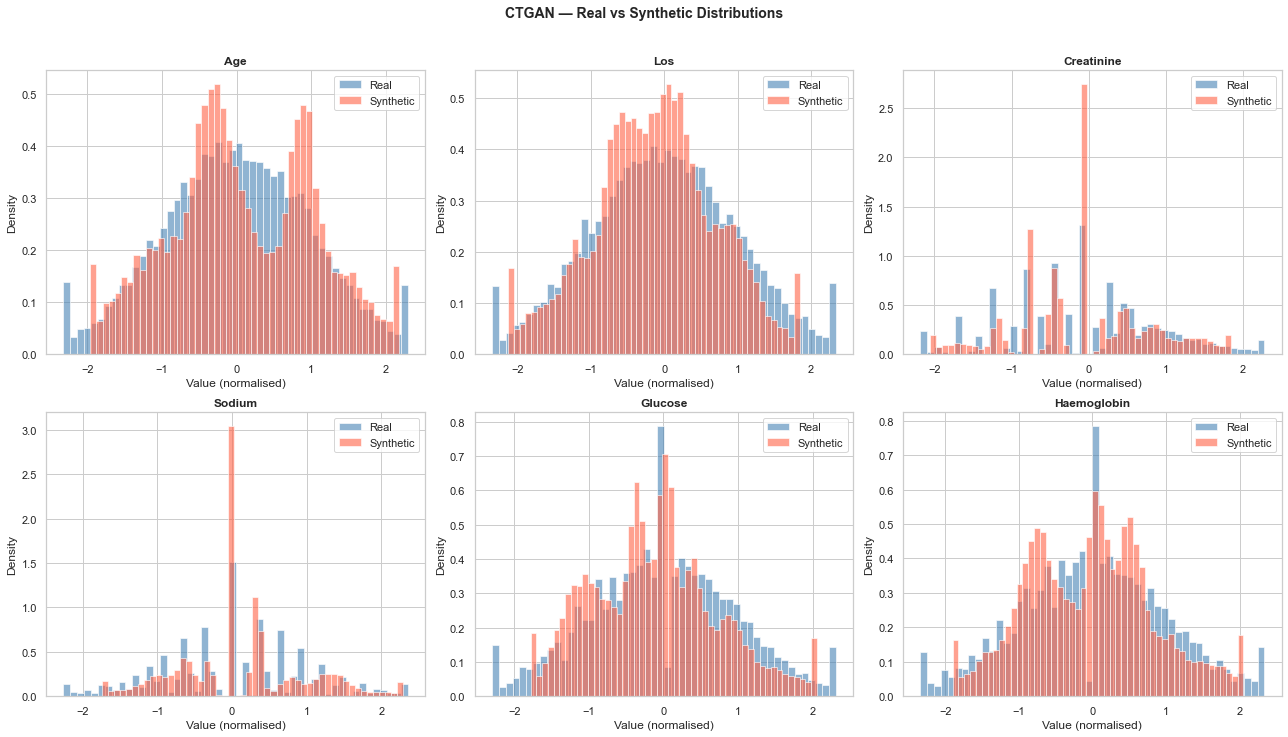

Comparison plot saved


In [9]:
# Plot real vs synthetic distributions
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

plot_cols = ['AGE', 'LOS', 'lab_creatinine', 
             'lab_sodium', 'lab_glucose', 'lab_haemoglobin']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    # Clip for display
    real_data = train_df[col].clip(
        train_df[col].quantile(0.01),
        train_df[col].quantile(0.99)
    )
    syn_data = synthetic_df[col].clip(
        synthetic_df[col].quantile(0.01),
        synthetic_df[col].quantile(0.99)
    )

    axes[i].hist(real_data, bins=50, alpha=0.6,
                 color='steelblue', label='Real', density=True)
    axes[i].hist(syn_data,  bins=50, alpha=0.6,
                 color='tomato',    label='Synthetic', density=True)
    axes[i].set_title(col.replace('lab_', '').title(),
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value (normalised)')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('CTGAN — Real vs Synthetic Distributions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

FIGURES_PATH = r"E:\Varsity Works\Dissertation\Code\results\figures"
os.makedirs(FIGURES_PATH, exist_ok=True)
plt.savefig(os.path.join(FIGURES_PATH, 'ctgan_real_vs_synthetic.png'),
            bbox_inches='tight')
plt.show()
print("Comparison plot saved")

In [10]:
# Save synthetic dataset
synthetic_path = os.path.join(SYNTHETIC_PATH, 'synthetic_ctgan.csv')
synthetic_df.to_csv(synthetic_path, index=False)

print(f" Synthetic data saved → {synthetic_path}")
print(f"  Shape:    {synthetic_df.shape}")
print(f"  Size:     "
      f"{os.path.getsize(synthetic_path) / 1024 / 1024:.1f} MB")

 Synthetic data saved → data\synthetic\synthetic_ctgan.csv
  Shape:    (25508, 34)
  Size:     7.8 MB


## Notebook 04 — CTGAN Training Complete

### Model Configuration
| Parameter | Value |
|-----------|-------|
| Epochs | 300 |
| Batch size | 500 |
| Generator dims | (256, 256) |
| Discriminator dims | (256, 256) |
| Learning rate | 2e-4 |
| Training patients | 25,508 |
| Synthetic patients generated | 25,508 |

### Output Files
- `models/ctgan_model.pkl` — trained model
- `data/synthetic/synthetic_ctgan.csv` — generated records
- `results/figures/ctgan_real_vs_synthetic.png` — visual comparison